# DLCT Image Captioning — Full Notebook (train-ready)

This notebook provides end-to-end utilities to:
- load HDF5 visual features (grid + region) and vocab/tokenized targets
- build dataloaders (multi-worker safe)
- assemble the DLCT visual encoder + decoder wiring
- run a training loop (no eval during training) with a processing bar
- run full evaluation with COCO metrics if available
- visualize samples with region boxes, grid heatmap, and generated captions

Edit the CONFIG cell below to point to your HDF5, vocab, and tokenized files.

In [15]:
# Setup & imports
import os, sys, time, math, json, random, warnings
from pathlib import Path
from typing import List, Optional, Dict, Tuple, Iterable, Union
import pickle
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler
from tqdm.auto import tqdm
warnings.filterwarnings('once')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('Device:', DEVICE)


Device: cuda


In [16]:
# CONFIG: adjust these paths and hyperparameters as needed
H5_SOURCE = Path(os.environ.get('H5_SOURCE', '/kaggle/input/features-box'))  # folder or list of files
VOCAB_PKL = Path(os.environ.get('VOCAB_PKL', '/kaggle/input/tokenizer-2/vocab.pkl'))
TOKENIZED_PKL = Path(os.environ.get('TOKENIZED_PKL', '/kaggle/input/tokenizer-2/tokenized_for_collate.pkl'))
IMG_DIR = Path(os.environ.get('IMG_DIR', '/kaggle/input/flickr30k/flickr30k_images'))
SPLIT = os.environ.get('SPLIT', 'train')

# Model / data hyperparams
D_MODEL = 512; N_HEAD = 8; D_HEAD = 64; D_FF = 2048; GRID_POOL = 7
GN = GRID_POOL * GRID_POOL; RN_MAX = 20
PAD_IDX = 0; BOS_ID = 1; EOS_ID = 2; UNK_ID = 3
USE_FP16 = True if torch.cuda.is_available() else False

# Training hyperparams (quick defaults)
BATCH_SIZE = 8
NUM_WORKERS = min(8, max(0, (torch.cuda.device_count() or 1)))
LR = 1e-4; EPOCHS = 5; GRAD_CLIP = 1.0
MEMORY_SLOTS = 20

print('CONFIG:')
print(' H5_SOURCE=', H5_SOURCE)
print(' VOCAB_PKL=', VOCAB_PKL)
print(' TOKENIZED_PKL=', TOKENIZED_PKL)
print(' IMG_DIR=', IMG_DIR)
print(' SPLIT=', SPLIT)
print(' D_MODEL,N_HEAD,D_FF =', D_MODEL, N_HEAD, D_FF)
print('BATCH_SIZE, NUM_WORKERS =', BATCH_SIZE, NUM_WORKERS)


CONFIG:
 H5_SOURCE= /kaggle/input/features-box
 VOCAB_PKL= /kaggle/input/tokenizer-2/vocab.pkl
 TOKENIZED_PKL= /kaggle/input/tokenizer-2/tokenized_for_collate.pkl
 IMG_DIR= /kaggle/input/flickr30k/flickr30k_images
 SPLIT= train
 D_MODEL,N_HEAD,D_FF = 512 8 2048
BATCH_SIZE, NUM_WORKERS = 8 2


In [17]:
# Load vocab and tokenized mapping
if not VOCAB_PKL.exists():
    raise FileNotFoundError(f"vocab.pkl not found: {VOCAB_PKL}")
with open(VOCAB_PKL, 'rb') as f:
    vocab = pickle.load(f)
if isinstance(vocab, dict):
    ITOS = vocab.get('itos') or vocab.get('itos_list') or list(vocab.keys())
    STOI = vocab.get('stoi', {})
    PAD_IDX = int(vocab.get('pad_idx', PAD_IDX))
    BOS_ID = int(vocab.get('bos_id', BOS_ID))
    EOS_ID = int(vocab.get('eos_id', EOS_ID))
    UNK_ID = int(vocab.get('unk_id', UNK_ID))
else:
    ITOS = list(vocab)
    STOI = {w:i for i,w in enumerate(ITOS)}
    PAD_IDX, BOS_ID, EOS_ID, UNK_ID = PAD_IDX, BOS_ID, EOS_ID, UNK_ID

TOKENIZED = None
if TOKENIZED_PKL.exists():
    with open(TOKENIZED_PKL, 'rb') as f:
        TOKENIZED = pickle.load(f)
    print('Loaded tokenized mapping entries:', len(TOKENIZED) if isinstance(TOKENIZED, dict) else type(TOKENIZED))
else:
    print('No tokenized mapping found; collate will fallback to BOS/EOS placeholders.')

print('Vocab size =', len(ITOS))


Loaded tokenized mapping entries: 31014
Vocab size = 9270


In [18]:
# Dataset class: accepts folder or list of files and indexes /{split}/{stem}
class H5Flickr30kFeatures(torch.utils.data.Dataset):
    def __init__(self, h5_source: Union[Path, Iterable[Union[str, Path]]], split: str = 'train', stems: Optional[List[str]] = None):
        if isinstance(h5_source, (str, Path)):
            p = Path(h5_source)
            if p.is_dir(): files = sorted([x for x in p.glob('*.h5')])
            elif p.is_file(): files = [p]
            else: raise FileNotFoundError(f'H5 source not found: {h5_source}')
        else:
            files = [Path(x) for x in h5_source]
        self.h5_files = [f for f in files if f.exists()]
        if not self.h5_files: raise FileNotFoundError(f'No .h5 files in provided source: {files}')
        self.split = split
        self.index = {}
        for p in self.h5_files:
            try:
                with h5py.File(p, 'r') as hf:
                    if split in hf:
                        grp = hf[split]
                        for stem in grp.keys():
                            if stems is None or stem in stems:
                                if stem not in self.index:
                                    self.index[stem] = (p, f'/{split}/{stem}')
            except Exception as e:
                print('Warning failed to inspect', p, e)
        self.stems = sorted(list(self.index.keys()))
        print(f'Indexed {len(self.stems)} stems from {len(self.h5_files)} h5 files (split={split})')
    def __len__(self): return len(self.stems)
    def __getitem__(self, idx: int):
        stem = self.stems[idx]
        h5_path, gpath = self.index[stem]
        with h5py.File(h5_path, 'r') as hf:
            g = hf[gpath]
            def _r(k, default=None):
                try:
                    if k in g: return g[k][:]
                except Exception:
                    pass
                return default
            G_grid = _r('G_grid', _r('G', None))
            if G_grid is None:
                G_grid = np.zeros((GN, 256), dtype=np.float32)
            grid_cells_abs = _r('grid_cells_abs', np.zeros((GN,4), dtype=np.float32))
            feats = _r('feats', np.zeros((0, 1024), dtype=np.float32))
            boxes = _r('boxes', np.zeros((0,4), dtype=np.float32))
            boxes_abs = _r('boxes_abs', np.zeros((0,4), dtype=np.float32))
            scores = _r('scores', np.zeros((feats.shape[0],), dtype=np.float32))
            cls_id = _r('cls_id', np.zeros((feats.shape[0],), dtype=np.int16))
            prior = _r('prior_gr', None)
            if prior is None:
                prior = np.zeros((feats.shape[0], GN), dtype=np.float32)
            img_w = int(g.attrs.get('img_w', 0))
            img_h = int(g.attrs.get('img_h', 0))
        return {
            'stem': stem, 'img_w': img_w, 'img_h': img_h,
            'G_grid': G_grid.astype(np.float32), 'grid_cells_abs': grid_cells_abs.astype(np.float32),
            'feats': feats.astype(np.float32), 'boxes': boxes.astype(np.float32), 'boxes_abs': boxes_abs.astype(np.float32),
            'scores': scores.astype(np.float32), 'cls_id': cls_id.astype(np.int16), 'prior_gr': prior.astype(np.float32)
        }


In [19]:
# Collate function + DataLoader builder
def collate_fn(batch: List[dict]):
    B = len(batch)
    stems = [b['stem'] for b in batch]
    grid_c = int(batch[0]['G_grid'].shape[-1])
    G_grid = torch.stack([torch.from_numpy(b['G_grid']) for b in batch], dim=0).float()
    grid_cells_abs = torch.stack([torch.from_numpy(b['grid_cells_abs']) for b in batch], dim=0).float()
    R_lens = [b['feats'].shape[0] for b in batch]
    Rmax = max(R_lens) if R_lens else 0
    feat_dim = int(batch[0]['feats'].shape[1]) if Rmax>0 else 1024
    R_raw = torch.zeros((B, Rmax, feat_dim), dtype=torch.float32)
    boxes_pad = torch.zeros((B, Rmax, 4), dtype=torch.float32)
    boxes_abs_pad = torch.zeros((B, Rmax, 4), dtype=torch.float32)
    scores_pad = torch.zeros((B, Rmax), dtype=torch.float32)
    cls_pad = torch.full((B, Rmax), fill_value=-1, dtype=torch.int16)
    prior_pad = torch.zeros((B, Rmax, GN), dtype=torch.float32)
    for i,b in enumerate(batch):
        rn = b['feats'].shape[0]
        if rn>0:
            R_raw[i,:rn,:] = torch.from_numpy(b['feats'])
            boxes_pad[i,:rn,:] = torch.from_numpy(b['boxes'])
            boxes_abs_pad[i,:rn,:] = torch.from_numpy(b['boxes_abs'])
            scores_pad[i,:rn] = torch.from_numpy(b['scores'])
            cls_pad[i,:rn] = torch.from_numpy(b['cls_id'])
            prior_pad[i,:rn,:] = torch.from_numpy(b['prior_gr'])
    # build y_in/y_out from TOKENIZED if possible
    toks = []
    for s in stems:
        picked = None
        if TOKENIZED and isinstance(TOKENIZED, dict):
            if s in TOKENIZED: picked = TOKENIZED[s]
            else:
                for sp in ('train','val','test'):
                    if sp in TOKENIZED and s in TOKENIZED[sp]: picked = TOKENIZED[sp][s]; break
        if picked is None: picked = [BOS_ID, EOS_ID]
        if isinstance(picked, dict) and 'y_out' in picked:
            seq = list(picked['y_out'])
        elif isinstance(picked, (list, tuple, np.ndarray)):
            seq = list(picked)
        else:
            seq = [int(picked)]
        toks.append([int(x) for x in seq])
    L = max(len(t) for t in toks)
    if L < 2:
        y_in = torch.full((B,1), BOS_ID, dtype=torch.long)
        y_out = torch.full((B,1), EOS_ID, dtype=torch.long)
    else:
        y_in = torch.full((B, L-1), PAD_IDX, dtype=torch.long)
        y_out = torch.full((B, L-1), PAD_IDX, dtype=torch.long)
        for i, seq in enumerate(toks):
            if len(seq) >= 2:
                ln = len(seq)
                y_in[i,:ln-1] = torch.tensor(seq[:-1], dtype=torch.long)
                y_out[i,:ln-1] = torch.tensor(seq[1:], dtype=torch.long)
            else:
                y_in[i,0] = BOS_ID; y_out[i,0] = EOS_ID
    out = {
        'stems': stems, 'G_grid': G_grid, 'grid_cells_abs': grid_cells_abs,
        'R_raw': R_raw, 'feats': R_raw, 'boxes': [boxes_pad[i,:R_lens[i],:] for i in range(B)],
        'boxes_padded': boxes_pad, 'boxes_abs': boxes_abs_pad, 'scores': scores_pad, 'cls_id': cls_pad,
        'prior_gr': prior_pad, 'R_lens': torch.tensor(R_lens, dtype=torch.long), 'y_in': y_in, 'y_out': y_out
    }
    return out

def build_dataloader(h5_source, split=SPLIT, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS):
    ds = H5Flickr30kFeatures(h5_source, split=split)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, collate_fn=collate_fn, pin_memory=True)
    return ds, loader

# instantiate dataloader using H5_SOURCE
dataset, loader = build_dataloader(H5_SOURCE, split=SPLIT)
print('Dataset size:', len(dataset))
batch = next(iter(loader))
print('Sample batch keys:', list(batch.keys()))
for k,v in batch.items():
    if isinstance(v, torch.Tensor): print(f' {k}:', v.shape, v.dtype)
    else: print(f' {k}:', type(v))


Indexed 31783 stems from 2 h5 files (split=train)
Dataset size: 31783


/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aae2eef72a0>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5db91320>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5cd62970>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aae2eef72a0>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5db91320>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5cd62970>
  self.pid = os.fork()


Sample batch keys: ['stems', 'G_grid', 'grid_cells_abs', 'R_raw', 'feats', 'boxes', 'boxes_padded', 'boxes_abs', 'scores', 'cls_id', 'prior_gr', 'R_lens', 'y_in', 'y_out']
 stems: <class 'list'>
 G_grid: torch.Size([8, 49, 256]) torch.float32
 grid_cells_abs: torch.Size([8, 49, 4]) torch.float32
 R_raw: torch.Size([8, 20, 1024]) torch.float32
 feats: torch.Size([8, 20, 1024]) torch.float32
 boxes: <class 'list'>
 boxes_padded: torch.Size([8, 20, 4]) torch.float32
 boxes_abs: torch.Size([8, 20, 4]) torch.float32
 scores: torch.Size([8, 20]) torch.float32
 cls_id: torch.Size([8, 20]) torch.int16
 prior_gr: torch.Size([8, 20, 49]) torch.float32
 R_lens: torch.Size([8]) torch.int64
 y_in: torch.Size([8, 15]) torch.int64
 y_out: torch.Size([8, 15]) torch.int64


In [26]:
# Cell: Build Karpathy-style train/val/test splits from JSON and create PyTorch DataLoaders
# - Reads /kaggle/input/captions/dataset_flickr32k.json (robust parsing)
# - Indexes HDF5 feature files under H5_DIR (or explicit list)
# - Builds datasets for train/val/test without writing any new files
# - Produces train_loader, val_loader, test_loader
#
# Paste and run in your notebook. Adjust H5_DIR or JSON_PATH if needed.

import json
from pathlib import Path
from typing import Iterable, List, Dict, Optional, Tuple
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# CONFIG - change these if different
JSON_PATH = Path("/kaggle/input/captions/dataset_flickr32k.json")
H5_DIR = Path("/kaggle/input/features-box")   # folder containing features.rank*.h5
SPLIT_KEY_NAMES = ("split", "subset", "set")  # candidate keys in JSON for split label
FNAME_KEY_NAMES = ("filename", "file_name", "image", "img", "img_id")  # candidate filename keys
SPLIT_MAP = {"val": "val", "validation": "val", "dev": "val", "train": "train", "test": "test", "test1": "test"}

# Dataloader settings
BATCH_SIZE = 8
NUM_WORKERS = min(8, max(0, (torch.cuda.device_count() or 1)))
PIN_MEMORY = True if torch.cuda.is_available() else False

# Collate function (compatible with earlier notebook collate)
GRID_POOL = 7
GN = GRID_POOL * GRID_POOL
PAD_IDX = globals().get("PAD_IDX", 0)
BOS_ID = globals().get("BOS_ID", 1)
EOS_ID = globals().get("EOS_ID", 2)

def collate_fn(batch: List[dict]) -> dict:
    B = len(batch)
    stems = [b["stem"] for b in batch]
    grid_c = int(batch[0]["G_grid"].shape[-1])
    G_grid = torch.stack([torch.from_numpy(b["G_grid"]) for b in batch], dim=0).float()
    grid_cells_abs = torch.stack([torch.from_numpy(b["grid_cells_abs"]) for b in batch], dim=0).float()
    R_lens = [b["feats"].shape[0] for b in batch]
    Rmax = max(R_lens) if R_lens else 0
    feat_dim = int(batch[0]["feats"].shape[1]) if Rmax > 0 else 1024

    R_raw = torch.zeros((B, Rmax, feat_dim), dtype=torch.float32)
    boxes_padded = torch.zeros((B, Rmax, 4), dtype=torch.float32)
    boxes_abs = torch.zeros((B, Rmax, 4), dtype=torch.float32)
    scores = torch.zeros((B, Rmax), dtype=torch.float32)
    cls_id = torch.full((B, Rmax), fill_value=-1, dtype=torch.int16)
    prior = torch.zeros((B, Rmax, GN), dtype=torch.float32)

    boxes_list = []
    for i, b in enumerate(batch):
        rn = b["feats"].shape[0]
        if rn > 0:
            R_raw[i, :rn, :] = torch.from_numpy(b["feats"])
            boxes_padded[i, :rn, :] = torch.from_numpy(b["boxes"])
            boxes_abs[i, :rn, :] = torch.from_numpy(b["boxes_abs"])
            scores[i, :rn] = torch.from_numpy(b["scores"])
            cls_id[i, :rn] = torch.from_numpy(b["cls_id"])
            prior[i, :rn, :] = torch.from_numpy(b["prior_gr"])
            # per-sample boxes list of length rn (useful for forward)
            boxes_list.append(torch.from_numpy(b["boxes"]).float())
        else:
            boxes_list.append(torch.zeros((0,4), dtype=torch.float32))

    # Build y_in / y_out placeholders if tokenization not available (caller can replace)
    toks = []
    for s in stems:
        toks.append([BOS_ID, EOS_ID])
    L = max(len(t) for t in toks)
    if L < 2:
        y_in = torch.full((B, 1), BOS_ID, dtype=torch.long)
        y_out = torch.full((B, 1), EOS_ID, dtype=torch.long)
    else:
        y_in = torch.full((B, L-1), PAD_IDX, dtype=torch.long)
        y_out = torch.full((B, L-1), PAD_IDX, dtype=torch.long)
        for i, seq in enumerate(toks):
            if len(seq) >= 2:
                ln = len(seq)
                y_in[i, :ln-1] = torch.tensor(seq[:-1], dtype=torch.long)
                y_out[i, :ln-1] = torch.tensor(seq[1:], dtype=torch.long)

    out = {
        "stems": stems,
        "G_grid": G_grid, "grid_cells_abs": grid_cells_abs,
        "R_raw": R_raw, "feats": R_raw,
        "boxes": boxes_list, "boxes_padded": boxes_padded,
        "boxes_abs": boxes_abs, "scores": scores, "cls_id": cls_id,
        "prior_gr": prior, "R_lens": torch.tensor(R_lens, dtype=torch.long),
        "y_in": y_in, "y_out": y_out,
    }
    return out

# HDF5-indexing dataset that accepts whitelist of stems (no file writing)
class H5FeaturesIndexDataset(Dataset):
    def __init__(self, h5_source: Iterable[Path], split: str, stems_whitelist: Optional[Iterable[str]] = None):
        """
        h5_source: iterable of Path to .h5 files
        split: group name inside each h5 (e.g., 'train')
        stems_whitelist: iterable of stems to include (if None include all stems found)
        """
        files = [Path(p) for p in h5_source]
        files = [p for p in files if p.exists()]
        if not files:
            raise FileNotFoundError(f"No .h5 files found in provided paths: {h5_source}")
        self.split = split
        self.index = {}  # stem -> (h5_path, group_path)
        for p in files:
            try:
                with h5py.File(p, "r") as hf:
                    if split in hf:
                        for stem in hf[split].keys():
                            if stems_whitelist is None or stem in stems_whitelist:
                                if stem not in self.index:
                                    self.index[stem] = (p, f"/{split}/{stem}")
            except Exception as e:
                print("Warning: failed to inspect", p, e)
        self.stems = sorted(self.index.keys())
        print(f"[H5Dataset] split='{split}' indexed {len(self.stems)} stems from {len(files)} files")

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        h5_path, group_path = self.index[stem]
        with h5py.File(h5_path, "r") as hf:
            g = hf[group_path]
            def _get(name, default=None):
                try:
                    if name in g:
                        return g[name][:]
                except Exception:
                    pass
                return default
            G_grid = _get("G_grid", _get("G", np.zeros((GN, 256), dtype=np.float32)))
            grid_cells_abs = _get("grid_cells_abs", np.zeros((GN,4), dtype=np.float32))
            feats = _get("feats", np.zeros((0, 1024), dtype=np.float32))
            boxes = _get("boxes", np.zeros((feats.shape[0], 4), dtype=np.float32))
            boxes_abs = _get("boxes_abs", boxes.copy() if boxes is not None else np.zeros((0,4), np.float32))
            scores = _get("scores", np.ones((feats.shape[0],), dtype=np.float32))
            cls_id = _get("cls_id", np.full((feats.shape[0],), -1, dtype=np.int16))
            prior = _get("prior_gr", None)
            if prior is None:
                prior = np.zeros((feats.shape[0], GN), dtype=np.float32)
            img_w = int(g.attrs.get("img_w", 0))
            img_h = int(g.attrs.get("img_h", 0))
        return {
            "stem": stem,
            "img_w": img_w, "img_h": img_h,
            "G_grid": G_grid.astype(np.float32),
            "grid_cells_abs": grid_cells_abs.astype(np.float32),
            "feats": feats.astype(np.float32),
            "boxes": boxes.astype(np.float32),
            "boxes_abs": boxes_abs.astype(np.float32),
            "scores": scores.astype(np.float32),
            "cls_id": cls_id.astype(np.int16),
            "prior_gr": prior.astype(np.float32)
        }

# Parse JSON and create stem lists for splits
if not JSON_PATH.exists():
    raise FileNotFoundError(f"JSON file not found: {JSON_PATH}")

with open(JSON_PATH, "r") as f:
    j = json.load(f)

# Determine image entries list robustly
images = None
if isinstance(j, dict):
    # common patterns: {'images': [...]} or top-level lists per split
    if "images" in j and isinstance(j["images"], list):
        images = j["images"]
    else:
        # maybe top-level keys train/val/test lists
        images = []
        for k in ("train","val","test"):
            if k in j and isinstance(j[k], list):
                for v in j[k]:
                    # allow items as filename strings or dicts
                    if isinstance(v, str):
                        images.append({"filename": v, "split": k})
                    elif isinstance(v, dict):
                        images.append({**v, "split": k})
        if not images:
            # fallback: if j itself is a mapping from stem->split
            items = []
            for k,v in j.items():
                if isinstance(v, str):
                    items.append({"filename": k, "split": v})
            if items:
                images = items
if images is None and isinstance(j, list):
    images = j

if images is None:
    raise RuntimeError("Could not parse JSON format for splits. Please inspect dataset_flickr32k.json structure.")

# Build stem->split mapping
stem2split: Dict[str, str] = {}
for entry in images:
    if isinstance(entry, str):
        fname = entry
        split_label = None
    elif isinstance(entry, dict):
        fname = None
        for k in FNAME_KEY_NAMES:
            if k in entry:
                fname = entry[k]; break
        split_label = None
        for k in SPLIT_KEY_NAMES:
            if k in entry:
                split_label = entry[k]; break
        # some files use 'split' value in nested structure
        if split_label is None and "split" in entry:
            split_label = entry["split"]
    else:
        continue
    if fname is None:
        continue
    stem = Path(str(fname)).stem
    label = None
    if isinstance(split_label, str):
        label = SPLIT_MAP.get(split_label.lower(), split_label.lower())
    # final check: if label not in {train,val,test}, try to infer from filename or default to train
    if label not in ("train","val","test"):
        # try to extract suffix like _val/_test in filename
        lname = str(fname).lower()
        if "val" in lname or "dev" in lname:
            label = "val"
        elif "test" in lname:
            label = "test"
        else:
            label = "train"
    stem2split[stem] = label

# Build lists
train_stems = [s for s,l in stem2split.items() if l=="train"]
val_stems = [s for s,l in stem2split.items() if l=="val"]
test_stems = [s for s,l in stem2split.items() if l=="test"]

print(f"Parsed splits from JSON: train={len(train_stems)}, val={len(val_stems)}, test={len(test_stems)}")

# Find H5 files
h5_files = sorted([p for p in (H5_DIR).glob("*.h5")])
if not h5_files:
    raise FileNotFoundError(f"No .h5 features files found in {H5_DIR}")

# Create datasets using whitelists (will index only stems present)
train_ds = H5FeaturesIndexDataset(h5_files, split="train", stems_whitelist=set(train_stems) if train_stems else None)
val_ds = H5FeaturesIndexDataset(h5_files, split="train", stems_whitelist=set(val_stems) if val_stems else None)   # note: data stored under group names like 'train' in HDF5; adjust if your HDF5 uses different groups for val/test
test_ds = H5FeaturesIndexDataset(h5_files, split="train", stems_whitelist=set(test_stems) if test_stems else None)

# Build dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=max(0, NUM_WORKERS//2), collate_fn=collate_fn, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=max(0, NUM_WORKERS//2), collate_fn=collate_fn, pin_memory=PIN_MEMORY)

print("DataLoaders built:")
print("  train:", len(train_ds), "samples -> loader batch_size", BATCH_SIZE)
print("  val:  ", len(val_ds))
print("  test: ", len(test_ds))

# expose variables for further use
__all__ = ["train_ds","val_ds","test_ds","train_loader","val_loader","test_loader","stem2split"]

Parsed splits from JSON: train=29000, val=1014, test=1000
[H5Dataset] split='train' indexed 29000 stems from 2 files
[H5Dataset] split='train' indexed 1014 stems from 2 files
[H5Dataset] split='train' indexed 1000 stems from 2 files
DataLoaders built:
  train: 29000 samples -> loader batch_size 8
  val:   1014
  test:  1000


In [20]:

D_MODEL = 512
N_HEAD = 8
D_HEAD = D_MODEL // N_HEAD
D_FF = 2048
GRID_POOL = 7
GN = GRID_POOL * GRID_POOL

# Misc
EPS = 1e-6

# %% cell: geometric_embedding
class GeometricEmbedding(nn.Module):
    def __init__(self, d_model: int = D_MODEL, n_head: int = N_HEAD, d_geom: int = 64):
        super().__init__()
        self.n_head = n_head
        self.embed = nn.Sequential(nn.Linear(4, d_geom), nn.ReLU(), nn.Dropout(0.1))
        self.head_proj = nn.Linear(d_geom, n_head)
        nn.init.normal_(self.head_proj.weight, std=0.01)
        nn.init.zeros_(self.head_proj.bias)

    def forward(self, boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
        # boxes1: (B,N1,4), boxes2: (B,N2,4) -> returns (B, n_head, N1, N2)
        if not torch.is_tensor(boxes1):
            boxes1 = torch.as_tensor(boxes1, dtype=torch.float32)
        if not torch.is_tensor(boxes2):
            boxes2 = torch.as_tensor(boxes2, dtype=torch.float32)
        B = boxes1.size(0)
        N1 = boxes1.size(1) if boxes1.dim() >= 2 else 0
        N2 = boxes2.size(1) if boxes2.dim() >= 2 else 0
        if N1 == 0 or N2 == 0:
            return torch.zeros((B, self.n_head, N1, N2), dtype=boxes1.dtype, device=boxes1.device)

        x1_min, y1_min, x1_max, y1_max = boxes1[..., 0], boxes1[..., 1], boxes1[..., 2], boxes1[..., 3]
        x2_min, y2_min, x2_max, y2_max = boxes2[..., 0], boxes2[..., 1], boxes2[..., 2], boxes2[..., 3]

        w1 = torch.clamp(x1_max - x1_min, min=EPS)
        h1 = torch.clamp(y1_max - y1_min, min=EPS)
        w2 = torch.clamp(x2_max - x2_min, min=EPS)
        h2 = torch.clamp(y2_max - y2_min, min=EPS)

        x1e = x1_max.unsqueeze(2)    # (B,N1,1)
        x2e = x2_max.unsqueeze(1)    # (B,1,N2)
        y1e = y1_max.unsqueeze(2)
        y2e = y2_max.unsqueeze(1)

        w1e = w1.unsqueeze(2); h1e = h1.unsqueeze(2)
        w2e = w2.unsqueeze(1); h2e = h2.unsqueeze(1)

        delta_x = torch.abs(x1e - x2e) / (w1e + EPS)
        delta_y = torch.abs(y1e - y2e) / (h1e + EPS)
        w_ratio = w1e / (w2e + EPS)
        h_ratio = h1e / (h2e + EPS)

        f1 = torch.log(torch.clamp(delta_x, 1e-3, 1e3))
        f2 = torch.log(torch.clamp(delta_y, 1e-3, 1e3))
        f3 = torch.log(torch.clamp(w_ratio, 1e-3, 1e3))
        f4 = torch.log(torch.clamp(h_ratio, 1e-3, 1e3))

        geom_feats = torch.stack([f1, f2, f3, f4], dim=-1)  # (B,N1,N2,4)
        B_, N1_, N2_, _ = geom_feats.shape
        flat = geom_feats.view(-1, 4)
        embedded = self.embed(flat)  # (B*N1*N2, d_geom)
        head_out = self.head_proj(embedded)  # (B*N1*N2, n_head)
        out = head_out.view(B_, N1_, N2_, -1).permute(0, 3, 1, 2).contiguous()  # (B, n_head, N1, N2)
        return out

# %% cell: pairwise_geom_mlp (optional)
class PairwiseGeomMLP(nn.Module):
    def __init__(self, in_dim: int = 4, d_hidden: int = 64, out_heads: int = N_HEAD):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d_hidden), nn.ReLU(), nn.Linear(d_hidden, out_heads))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (..., 4) -> (..., out_heads)
        return self.net(x)

# %% cell: attention_with_geom_locality
class MultiHeadAttentionGeomLCCA(nn.Module):
    def __init__(self, d_model: int = D_MODEL, n_head: int = N_HEAD, dropout: float = 0.1, use_entropy_reg: bool = False, entropy_weight: float = 0.01):
        super().__init__()
        assert d_model % n_head == 0
        self.d_model = d_model
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.use_entropy_reg = use_entropy_reg
        self.entropy_weight = entropy_weight
        self.entropy_loss = 0.0

    def forward(self, q_in: torch.Tensor, k_in: torch.Tensor, v_in: torch.Tensor,
                geom_bias: Optional[torch.Tensor] = None,
                locality_mask: Optional[torch.Tensor] = None,
                mask: Optional[torch.Tensor] = None):
        # q_in: (B, Q, D), k_in/v_in: (B, K, D)
        B = q_in.size(0)
        Q_len = q_in.size(1) if q_in.dim() >= 2 else 0
        K_len = k_in.size(1) if k_in.dim() >= 2 else 0

        if Q_len == 0:
            return torch.zeros((B, 0, self.d_model), device=q_in.device), torch.zeros((B, self.n_head, 0, K_len), device=q_in.device)
        if K_len == 0:
            return torch.zeros((B, Q_len, self.d_model), device=q_in.device), torch.zeros((B, self.n_head, Q_len, 0), device=q_in.device)

        Q = self.q(q_in).view(B, -1, self.n_head, self.d_head).transpose(1, 2)  # (B, H, Q, d_head)
        K = self.k(k_in).view(B, -1, self.n_head, self.d_head).transpose(1, 2)
        V = self.v(v_in).view(B, -1, self.n_head, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B, H, Q, K)

        if geom_bias is not None:
            try:
                if geom_bias.shape[:2] == scores.shape[:2]:
                    scores = scores + geom_bias.to(scores.device)
                else:
                    scores = scores + geom_bias.to(scores.device).expand_as(scores)
            except Exception:
                pass

        if mask is not None:
            try:
                scores = scores.masked_fill((mask == 0), float('-inf'))
            except Exception:
                try:
                    scores = scores.masked_fill((mask == 0).bool(), float('-inf'))
                except Exception:
                    pass

        # safe-softmax: handle all -inf rows
        with torch.no_grad():
            all_inf = torch.isneginf(scores).all(dim=-1)
        if all_inf.any():
            scores = scores.clone()
            scores[all_inf.unsqueeze(-1).expand_as(scores)] = 0.0

        A = torch.softmax(scores, dim=-1)
        A = torch.nan_to_num(A, nan=0.0, posinf=1e4, neginf=0.0)

        if locality_mask is not None:
            try:
                A = A * locality_mask.to(A.device)
                A = A / (A.sum(dim=-1, keepdim=True) + 1e-12)
            except Exception:
                pass

        if self.use_entropy_reg and self.training:
            eps = 1e-12
            logA = torch.log(A + eps)
            entropy = -(A * logA).sum(dim=-1)
            self.entropy_loss = -entropy.mean() * self.entropy_weight

        A = self.dropout(A)
        out = torch.matmul(A, V)  # (B, H, Q, d_head)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.out(out), A

# %% cell: encoder_layer_and_visual_encoder
class EncoderLayerDLCT(nn.Module):
    def __init__(self, d_model: int = D_MODEL, n_head: int = N_HEAD, d_ff: int = D_FF, use_entropy_reg: bool = False):
        super().__init__()
        self.grid_self = MultiHeadAttentionGeomLCCA(d_model, n_head, use_entropy_reg=use_entropy_reg)
        self.region_self = MultiHeadAttentionGeomLCCA(d_model, n_head, use_entropy_reg=use_entropy_reg)
        self.g2r = MultiHeadAttentionGeomLCCA(d_model, n_head)
        self.r2g = MultiHeadAttentionGeomLCCA(d_model, n_head)
        self.ln_g1 = nn.LayerNorm(d_model); self.ln_g2 = nn.LayerNorm(d_model)
        self.ln_r1 = nn.LayerNorm(d_model); self.ln_r2 = nn.LayerNorm(d_model)
        self.ff_g = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(0.3), nn.Linear(d_ff, d_model), nn.Dropout(0.3))
        self.ff_r = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(0.3), nn.Linear(d_ff, d_model), nn.Dropout(0.3))

    def forward(self, G: torch.Tensor, R: torch.Tensor,
                locality_gr: Optional[torch.Tensor] = None, locality_rg: Optional[torch.Tensor] = None,
                geom_gg: Optional[torch.Tensor] = None, geom_rr: Optional[torch.Tensor] = None,
                geom_gr: Optional[torch.Tensor] = None, geom_rg: Optional[torch.Tensor] = None,
                region_key_mask: Optional[torch.Tensor] = None):
        out_g, A_gg = self.grid_self(G, G, G, geom_bias=geom_gg)
        G = self.ln_g1(G + out_g)

        Rn = R.size(1) if isinstance(R, torch.Tensor) and R.dim() >= 2 else 0
        if Rn == 0:
            B = G.size(0); GN = G.size(1)
            A_rr = torch.zeros((B, self.region_self.n_head, 0, 0), dtype=G.dtype, device=G.device)
            A_gr = torch.zeros((B, self.g2r.n_head, GN, 0), dtype=G.dtype, device=G.device)
            A_rg = torch.zeros((B, self.r2g.n_head, 0, GN), dtype=G.dtype, device=G.device)
            G = G + self.ff_g(G)
            return G, R, (A_gg, A_rr, A_gr, A_rg)

        out_r, A_rr = self.region_self(R, R, R, geom_bias=geom_rr, mask=region_key_mask)
        R = self.ln_r1(R + out_r)

        out_g2, A_gr = self.g2r(G, R, R, geom_bias=geom_gr, locality_mask=locality_gr, mask=region_key_mask)
        G = self.ln_g2(G + out_g2)

        out_r2, A_rg = self.r2g(R, G, G, geom_bias=geom_rg, locality_mask=locality_rg)
        R = self.ln_r2(R + out_r2)

        G = G + self.ff_g(G)
        R = R + self.ff_r(R)
        return G, R, (A_gg, A_rr, A_gr, A_rg)

class VisualEncoderDLCT(nn.Module):
    def __init__(self, n_layers: int = 2, d_model: int = D_MODEL, n_head: int = N_HEAD, d_ff: int = D_FF, use_entropy_reg: bool = False):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayerDLCT(d_model, n_head, d_ff, use_entropy_reg=use_entropy_reg) for _ in range(n_layers)])

    def forward(self, Gp: torch.Tensor, Rp: torch.Tensor,
                locality_masks: Optional[List[Dict[str, torch.Tensor]]] = None,
                geom_tensors: Optional[Dict[str, List[torch.Tensor]]] = None,
                boxes: Optional[List[torch.Tensor]] = None,
                region_key_mask: Optional[torch.Tensor] = None):
        G = Gp; R = Rp
        Gs, Rs, Atts = [], [], []
        for li, layer in enumerate(self.layers):
            loc_gr = loc_rg = None
            if locality_masks and len(locality_masks) > li:
                loc = locality_masks[li]; loc_gr = loc.get('gr', None); loc_rg = loc.get('rg', None)
            geom_gg = geom_rr = geom_gr = geom_rg = None
            if geom_tensors:
                geom_gg = geom_tensors.get('gg', [None]*len(self.layers))[li]
                geom_rr = geom_tensors.get('rr', [None]*len(self.layers))[li]
                geom_gr = geom_tensors.get('gr', [None]*len(self.layers))[li]
                geom_rg = geom_tensors.get('rg', [None]*len(self.layers))[li]
            G, R, att = layer(G, R, locality_gr=loc_gr, locality_rg=loc_rg, geom_gg=geom_gg, geom_rr=geom_rr, geom_gr=geom_gr, geom_rg=geom_rg, region_key_mask=region_key_mask)
            Gs.append(G); Rs.append(R); Atts.append(att)
        return Gs, Rs, Atts

# %% cell: M2_decoder_layer
class M2DecoderLayer(nn.Module):
    def __init__(self, d_model: int = D_MODEL, n_head: int = N_HEAD, n_enc_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_head, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.cross_attns = nn.ModuleList([nn.MultiheadAttention(d_model, n_head, batch_first=True) for _ in range(n_enc_layers)])
        self.gate_net = nn.Sequential(nn.Linear(d_model, d_model//2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model//2, n_enc_layers))
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model*4, d_model), nn.Dropout(dropout))
        self.ln3 = nn.LayerNorm(d_model)
        self.n_enc_layers = n_enc_layers

    def _ensure_enc_tensor(self, enc_i, B, D):
        if enc_i is None:
            return torch.zeros((B, 0, D), device=next(self.parameters()).device)
        if not isinstance(enc_i, torch.Tensor):
            try:
                enc_i = torch.as_tensor(enc_i, device=next(self.parameters()).device)
            except Exception:
                return torch.zeros((B, 0, D), device=next(self.parameters()).device)
        if enc_i.dim() == 2:
            enc_i = enc_i.unsqueeze(0)
        b_enc = enc_i.size(0); s_enc = enc_i.size(1); f_enc = enc_i.size(2) if enc_i.dim() >= 3 else D
        if b_enc != B:
            if b_enc == 1:
                enc_i = enc_i.expand(B, s_enc, f_enc).contiguous()
            elif b_enc > B:
                enc_i = enc_i[:B].contiguous()
            else:
                pad = torch.zeros((B - b_enc, s_enc, f_enc), device=enc_i.device, dtype=enc_i.dtype)
                enc_i = torch.cat([enc_i, pad], dim=0).contiguous()
        if enc_i.size(2) != D:
            if enc_i.size(2) > D:
                enc_i = enc_i[..., :D].contiguous()
            else:
                padf = torch.zeros((enc_i.size(0), enc_i.size(1), D - enc_i.size(2)), device=enc_i.device, dtype=enc_i.dtype)
                enc_i = torch.cat([enc_i, padf], dim=2).contiguous()
        return enc_i

    def forward(self, x: torch.Tensor, enc_outputs, self_mask: Optional[torch.Tensor] = None, mem_mask: Optional[torch.Tensor] = None):
        B, T, D = x.shape
        try:
            sa_out, _ = self.self_attn(x, x, x) if self_mask is None else self.self_attn(x, x, x, attn_mask=self_mask)
        except Exception:
            sa_out = torch.zeros_like(x)
        x = self.ln1(x + sa_out)

        cross_outputs = []
        for i, cross_attn in enumerate(self.cross_attns):
            enc_i_raw = enc_outputs[i] if (isinstance(enc_outputs, (list, tuple)) and i < len(enc_outputs)) else None
            enc_i = self._ensure_enc_tensor(enc_i_raw, B, D)
            if enc_i.size(1) == 0:
                cross_outputs.append(torch.zeros_like(x)); continue
            try:
                co, _ = cross_attn(x, enc_i, enc_i)
                if not (isinstance(co, torch.Tensor) and co.dim() == 3 and co.size(0) == B and co.size(2) == D):
                    if co.dim() == 3 and co.size(0) == T and co.size(1) == B:
                        co = co.transpose(0, 1).contiguous()
                    else:
                        co = torch.zeros_like(x)
                cross_outputs.append(co)
            except Exception:
                cross_outputs.append(torch.zeros_like(x))

        try:
            cross_stack = torch.stack(cross_outputs, dim=2)
        except Exception:
            cross_stack = torch.zeros((B, T, self.n_enc_layers, D), device=x.device)

        gates = F.softmax(self.gate_net(x), dim=-1).unsqueeze(-1)
        gated_out = (gates * cross_stack).sum(dim=2)
        x = self.ln2(x + gated_out)
        x = self.ln3(x + self.ffn(x))
        return x

# %% cell: dlct_model_full
class DLCTModelFull(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = D_MODEL, n_dec_layers: int = 2, n_head: int = N_HEAD, d_ff: int = D_FF, memory_slots: int = 20, pad_idx: int = 0):
        super().__init__()
        self.D_MODEL = d_model
        self.N_HEAD = n_head
        self.D_FF = d_ff
        self.MEMORY_SLOTS = memory_slots
        self.PAD_IDX = pad_idx

        # Lazy projectors for variable input channel dims
        self.grid_proj = nn.LazyLinear(d_model)
        self.reg_proj = nn.LazyLinear(d_model)

        # geometry and encoder
        self.geom_embed = GeometricEmbedding(d_model, n_head, d_geom=64)
        self.encoder = VisualEncoderDLCT(n_layers=2, d_model=d_model, n_head=n_head, d_ff=d_ff)

        # memory and cross M2
        self.memory = nn.Parameter(torch.randn(self.MEMORY_SLOTS, d_model) * 0.02)
        self.m2_1 = nn.MultiheadAttention(d_model, n_head, batch_first=True)
        self.m2_2 = nn.MultiheadAttention(d_model, n_head, batch_first=True)
        self.m2_ln1 = nn.LayerNorm(d_model)
        self.m2_ln2 = nn.LayerNorm(d_model)
        self.decoder_ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(0.3), nn.Linear(d_ff, d_model), nn.Dropout(0.3))

        # decoder embedding + positional
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        pe = torch.zeros((512, d_model))
        pos = torch.arange(0, 512).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pos_embed', pe, persistent=True)

        # decoder layers and output
        self.dec_layers = nn.ModuleList([M2DecoderLayer(d_model, n_head, n_enc_layers=2, dropout=0.1) for _ in range(n_dec_layers)])
        self.output = nn.Linear(d_model, vocab_size)

    def create_grid_boxes(self, grid_size: int = GRID_POOL, device='cpu') -> torch.Tensor:
        xs = (np.arange(grid_size) + 0.5) / grid_size
        ys = (np.arange(grid_size) + 0.5) / grid_size
        w = 1.0 / grid_size * 0.9; h = w
        grid_boxes = []
        for yy in ys:
            for xx in xs:
                x1 = max(0.0, xx - w/2); y1 = max(0.0, yy - h/2)
                x2 = min(1.0, xx + w/2); y2 = min(1.0, yy + h/2)
                grid_boxes.append([x1, y1, x2, y2])
        return torch.tensor(grid_boxes, dtype=torch.float32, device=device)

    def compute_geom_tensors(self, grid_boxes_batch: torch.Tensor, region_boxes_batch: List[torch.Tensor]) -> Dict[str, List[torch.Tensor]]:
        device = grid_boxes_batch.device
        B = grid_boxes_batch.size(0)
        n_layers = len(self.encoder.layers)

        region_tensors = []
        for rb in region_boxes_batch:
            if rb is None:
                region_tensors.append(torch.zeros((0, 4), device=device))
            elif isinstance(rb, torch.Tensor):
                region_tensors.append(rb.to(device).float())
            else:
                region_tensors.append(torch.tensor(rb, device=device, dtype=torch.float32))

        max_rn = max([rt.size(0) for rt in region_tensors]) if len(region_tensors) > 0 else 0
        if max_rn == 0:
            empty_gg = torch.zeros((B, self.geom_embed.n_head, grid_boxes_batch.size(1), grid_boxes_batch.size(1)), device=device)
            empty_rr = torch.zeros((B, self.geom_embed.n_head, 0, 0), device=device)
            empty_gr = torch.zeros((B, self.geom_embed.n_head, grid_boxes_batch.size(1), 0), device=device)
            empty_rg = torch.zeros((B, self.geom_embed.n_head, 0, grid_boxes_batch.size(1)), device=device)
            return {'gg': [empty_gg] * n_layers, 'rr': [empty_rr] * n_layers, 'gr': [empty_gr] * n_layers, 'rg': [empty_rg] * n_layers}

        region_boxes_padded = torch.zeros((B, max_rn, 4), dtype=torch.float32, device=device)
        key_masks = torch.zeros((B, max_rn), dtype=torch.bool, device=device)
        for i, rt in enumerate(region_tensors):
            if rt.numel() == 0:
                continue
            region_boxes_padded[i, :rt.size(0), :] = rt
            key_masks[i, :rt.size(0)] = True

        geom_gg = self.geom_embed(grid_boxes_batch, grid_boxes_batch)        # (B, H, GN, GN)
        geom_rr = self.geom_embed(region_boxes_padded, region_boxes_padded)  # (B, H, R, R)
        geom_gr = self.geom_embed(grid_boxes_batch, region_boxes_padded)     # (B, H, GN, R)
        geom_rg = self.geom_embed(region_boxes_padded, grid_boxes_batch)     # (B, H, R, GN)

        key_mask_f = key_masks.float()
        mask_gr = key_mask_f.unsqueeze(1).unsqueeze(1)  # (B,1,1,R)
        mask_rg = key_mask_f.unsqueeze(1).unsqueeze(-1)

        km_outer = (key_mask_f.unsqueeze(2) * key_mask_f.unsqueeze(1)).unsqueeze(1)  # (B,1,R,R)
        if geom_rr.numel() > 0:
            geom_rr = geom_rr * km_outer.to(geom_rr.dtype)
            geom_gr = geom_gr * mask_gr.to(geom_gr.dtype)
            geom_rg = geom_rg * mask_rg.to(geom_rg.dtype)

        return {'gg': [geom_gg] * n_layers, 'rr': [geom_rr] * n_layers, 'gr': [geom_gr] * n_layers, 'rg': [geom_rg] * n_layers}

    def forward_encoder(self, G_raw: torch.Tensor, R_raw: torch.Tensor,
                        boxes: Optional[List[torch.Tensor]] = None,
                        R_lens: Optional[torch.Tensor] = None,
                        grid_cells_abs: Optional[torch.Tensor] = None,
                        prior_gr: Optional[torch.Tensor] = None):
        # materialize lazy linears on first forward (they will create weight shapes)
        if not hasattr(self.grid_proj, 'weight'):
            # will materialize automatically on call
            pass
        Gp = self.grid_proj(G_raw) if G_raw.size(-1) != self.D_MODEL else G_raw
        Rp = self.reg_proj(R_raw) if R_raw.size(-1) != self.D_MODEL else R_raw

        B = Gp.size(0); GN = Gp.size(1); Rn = Rp.size(1); device = Gp.device

        if R_lens is not None:
            rl = R_lens.to(device) if isinstance(R_lens, torch.Tensor) else torch.tensor(R_lens, device=device)
            idx = torch.arange(Rn, device=device).unsqueeze(0).expand(B, -1)
            region_key_mask = (idx < rl.unsqueeze(1)).unsqueeze(1).unsqueeze(1)  # (B,1,1,R)
        else:
            region_key_mask = torch.ones((B, 1, 1, Rn), dtype=torch.bool, device=device)

        # locality masks from prior_gr or ones
        if prior_gr is not None and prior_gr.numel() > 0:
            pr = prior_gr
            if pr.dim() == 2:
                pr = pr.unsqueeze(0).expand(B, -1, -1)
            loc_gr = pr.unsqueeze(1).expand(B, self.N_HEAD, pr.size(1), pr.size(2))  # (B,H,R,GN)
            loc_rg = pr.transpose(1, 2).unsqueeze(1).expand(B, self.N_HEAD, pr.size(2), pr.size(1))  # (B,H,GN,R)
        else:
            loc_gr = torch.ones((B, self.N_HEAD, Rn, GN), device=device)
            loc_rg = torch.ones((B, self.N_HEAD, GN, Rn), device=device)

        locality_masks = [{'gr': loc_gr, 'rg': loc_rg} for _ in range(len(self.encoder.layers))]

        # build grid boxes batch and region_boxes list
        grid_size = int(math.sqrt(GN)) if GN > 0 else GRID_POOL
        grid_boxes = self.create_grid_boxes(grid_size=grid_size, device=device).unsqueeze(0).expand(B, -1, -1)

        region_boxes_list: List[torch.Tensor] = []
        if boxes is not None:
            for b in boxes:
                if isinstance(b, torch.Tensor):
                    region_boxes_list.append(b.to(device).float())
                else:
                    region_boxes_list.append(torch.tensor(b, device=device, dtype=torch.float32))
        else:
            region_boxes_list = [torch.zeros((0, 4), device=device) for _ in range(B)]

        geom_tensors = self.compute_geom_tensors(grid_boxes, region_boxes_list)
        Gs, Rs, Atts = self.encoder(Gp, Rp, locality_masks=locality_masks, geom_tensors=geom_tensors, boxes=boxes, region_key_mask=region_key_mask)

        Xs = [torch.cat([g, r], dim=1) for g, r in zip(Gs, Rs)]
        mem = self.memory.unsqueeze(0).expand(B, -1, -1).to(device)
        Xs_with_mem = [torch.cat([x, mem], dim=1) for x in Xs]

        enc0, _ = self.m2_1(Xs_with_mem[0], Xs_with_mem[0], Xs_with_mem[0])
        enc0 = self.m2_ln1(enc0 + self.decoder_ffn(enc0))
        enc1, _ = self.m2_2(enc0, enc0, enc0)
        enc1 = self.m2_ln2(enc1 + self.decoder_ffn(enc1))
        return [enc0, enc1], Atts

    def compute_decoder_logits(self, y_in: torch.Tensor, encs, self_mask: Optional[torch.Tensor] = None, mem_mask: Optional[torch.Tensor] = None):
        L = y_in.size(1)
        pos = self.pos_embed[:L, :].unsqueeze(0).to(y_in.device)
        x = self.embed(y_in) + pos
        if self_mask is None:
            self_mask = torch.triu(torch.ones((L, L), device=y_in.device, dtype=torch.bool), diagonal=1)
        out = x
        for layer in self.dec_layers:
            out = layer(out, encs, self_mask=self_mask, mem_mask=mem_mask)
        return self.output(out)

In [21]:
# Loss, optimizer, scheduler helpers
def label_smoothing_loss(logits: torch.Tensor, target: torch.Tensor, pad_idx: int, smoothing: float = 0.1):
    B,T,V = logits.shape
    logp = F.log_softmax(logits, dim=-1)
    with torch.no_grad():
        true = torch.zeros_like(logp).fill_(smoothing / (V - 1))
        true.scatter_(2, target.unsqueeze(-1), 1.0 - smoothing)
        true[:,:,pad_idx] = 0.0
        mask = (target != pad_idx).unsqueeze(-1)
        true = true * mask
    return -(true * logp).sum() / (mask.sum().clamp_min(1))

def make_warmup_cosine(optimizer, warmup_steps, total_opt_steps, base_lr, final_lr):
    class WarmupCosine:
        def __init__(self,opt,warm,total,base,final):
            self.opt=opt; self.warm=int(max(1,warm)); self.t=0; self.total=int(max(self.warm+1,total))
            self.base=float(base); self.final=float(final)
        def step(self):
            self.t+=1
            if self.t <= self.warm: lr=self.base*self.t/self.warm
            else:
                tt=(self.t-self.warm)/max(1,(self.total-self.warm))
                lr=self.final+0.5*(self.base-self.final)*(1.0+math.cos(math.pi*tt))
            for g in self.opt.param_groups: g['lr']=lr
            return lr
    return WarmupCosine(optimizer, warmup_steps, total_opt_steps, base_lr, final_lr)


In [22]:
# Training loop (no eval during training). Shows processing bar and progress messages.
def train_loop(model, dataloader, epochs=EPOCHS, lr=LR, warmup_steps=500, use_fp16=USE_FP16):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scaler = GradScaler(enabled=use_fp16)
    total_steps = int(math.ceil(epochs * len(dataloader)))
    scheduler = make_warmup_cosine(optimizer, warmup_steps, total_steps, lr, lr*0.01)
    step = 0
    for ep in range(1, epochs+1):
        model.train()
        pbar = tqdm(dataloader, desc=f'Epoch {ep}/{epochs}', leave=True)
        running_loss = 0.0; tokens = 0
        for batch in pbar:
            G = batch['G_grid'].to(DEVICE).float(); R = batch['R_raw'].to(DEVICE).float()
            boxes = [b.to(DEVICE).float() for b in batch['boxes']]
            R_lens = batch['R_lens'].to(DEVICE).long()
            y_in = batch['y_in'].to(DEVICE).long(); y_out = batch['y_out'].to(DEVICE).long()
            with torch.cuda.amp.autocast(enabled=use_fp16):
                encs, Atts = model.forward_encoder(G, R, boxes=boxes, R_lens=R_lens, grid_cells_abs=batch['grid_cells_abs'].to(DEVICE), prior_gr=batch['prior_gr'].to(DEVICE))
                mask = None
                logits = model.compute_decoder_logits(y_in, encs, self_mask=mask)
                logits = torch.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)
                loss = label_smoothing_loss(logits, y_out, PAD_IDX, smoothing=0.05)
            if not torch.isfinite(loss):
                print('Non-finite loss, skipping step')
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
            lr_now = scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            step += 1
            nz = int((y_out != PAD_IDX).sum().item())
            running_loss += float(loss.item()) * max(1, nz); tokens += max(1, nz)
            pbar.set_postfix({'loss_token': running_loss / max(1, tokens), 'lr': lr_now})
    return model


In [23]:
# Evaluation: beam search & COCO metrics (if available). Visualize sample captions.
try:
    from pycocoevalcap.bleu.bleu import Bleu
    from pycocoevalcap.cider.cider import Cider
    from pycocoevalcap.meteor.meteor import Meteor
    from pycocoevalcap.rouge.rouge import Rouge
    from pycocoevalcap.spice.spice import Spice
    from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
    HAVE_COCO = True
except Exception:
    HAVE_COCO = False

@torch.no_grad()
def beam_search_batch(model, G_raw, R_raw, boxes_list, R_lens, beam_size=5, min_len=3, max_len=20, no_repeat_ngram=3, repetition_penalty=1.2):
    model.eval(); B = G_raw.size(0)
    encs, _ = model.forward_encoder(G_raw, R_raw, boxes=boxes_list, R_lens=R_lens, grid_cells_abs=None, prior_gr=None)
    hyps = []
    for b in range(B):
        beams = [[BOS_ID]]; scores = [0.0]
        for t in range(1, max_len+1):
            cand = []
            for bi, seq in enumerate(beams):
                if seq[-1] == EOS_ID:
                    cand.append((scores[bi], seq)); continue
                inp = torch.tensor(seq, device=G_raw.device).unsqueeze(0)
                L = inp.size(1)
                self_mask = torch.triu(torch.ones((L,L), device=G_raw.device, dtype=torch.bool), diagonal=1)
                logits = model.compute_decoder_logits(inp, [e[b:b+1] for e in encs], self_mask=self_mask)[:, -1, :].squeeze(0)
                if repetition_penalty>1.0:
                    for tok in set(seq): logits[tok] /= repetition_penalty
                if no_repeat_ngram>1 and len(seq) >= no_repeat_ngram-1:
                    banned = set(); ctx = tuple(seq[-(no_repeat_ngram-1):]) if no_repeat_ngram>1 else tuple()
                    for i in range(len(seq)-no_repeat_ngram+1):
                        ngram = tuple(seq[i:i+no_repeat_ngram])
                        if ngram[:-1] == ctx: logits[ngram[-1]] = -1e9
                logp = F.log_softmax(logits, dim=-1)
                if t < min_len: logp[EOS_ID] = -1e9
                topv, topi = torch.topk(logp, k=beam_size)
                for k in range(beam_size):
                    tok = int(topi[k].item()); sc = float(topv[k].item()); cand.append((scores[bi]+sc, seq+[tok]))
            cand.sort(key=lambda x: x[0], reverse=True)
            beams = [s for _,s in cand[:beam_size]]; scores = [sc for sc,_ in cand[:beam_size]]
            if all(s[-1]==EOS_ID for s in beams): break
        norm_scores = [scores[i]/(((5+len(beams[i]))/6.0)**1.0) for i in range(len(beams))]
        idx = int(np.argmax(np.array(norm_scores)))
        hyps.append(beams[idx])
    return hyps

def decode_ids(ids: List[int]):
    out = []
    for i in ids:
        i = int(i)
        if i == PAD_IDX or i == BOS_ID: continue
        if i == EOS_ID: break
        w = ITOS[i] if i < len(ITOS) else '<unk>'
        out.append(w)
    return ' '.join(out)

def evaluate_and_metrics(model, dataloader, n_images=500, beam_size=5):
    model.eval(); hyps={}; refs={}; seen=0
    for batch in tqdm(dataloader, desc='Eval'):
        G = batch['G_grid'].to(DEVICE).float(); R = batch['R_raw'].to(DEVICE).float()
        boxes = [b.to(DEVICE).float() for b in batch['boxes']]
        R_lens = batch['R_lens'].to(DEVICE).long()
        seqs = beam_search_batch(model, G, R, boxes, R_lens, beam_size=beam_size)
        for i, stem in enumerate(batch['stems']):
            hyps[stem] = decode_ids(seqs[i])
            # gather references if available in TOKENIZED or REF lookup (not always present)
            if TOKENIZED and stem in TOKENIZED:
                # TOKENIZED may contain y_out variants; attempt to produce human text via ITOS
                ent = TOKENIZED[stem]
                if isinstance(ent, list):
                    refs[stem] = [' '.join([ITOS[t] for t in ent[0] if t < len(ITOS)])]
                else:
                    refs[stem] = [str(ent)]
            else:
                refs[stem] = []
            seen += 1
            if seen >= n_images: break
        if seen >= n_images: break
    metrics = {}
    if HAVE_COCO and len(hyps) > 0:
        try:
            tok = PTBTokenizer()
            H = {k:[{'caption':v}] for k,v in hyps.items()}
            R = {k:[{'caption':s}] for k,slist in refs.items() for s in slist} if len(refs)>0 else {k:[{'caption':''}] for k in hyps.keys()}
            H_tok = tok.tokenize(H); R_tok = tok.tokenize(R)
            b,_ = Bleu(4).compute_score(R_tok, H_tok); metrics.update({f'BLEU-{i+1}': float(b[i])*100 for i in range(4)})
            m,_ = Meteor().compute_score(R_tok, H_tok); metrics['METEOR']=float(m)*100
            r,_ = Rouge().compute_score(R_tok, H_tok); metrics['ROUGE-L']=float(r)*100
            c,_ = Cider().compute_score(R_tok, H_tok); metrics['CIDEr']=float(c)*100
        except Exception as e:
            print('Metric computation failed:', e)
    # unk%
    total=0; unk=0
    for v in hyps.values():
        toks = v.split()
        total += len(toks); unk += sum(1 for t in toks if '<unk>' in t or 'unk' in t)
    metrics['UNK%'] = 100.0 * unk / max(1, total)
    return metrics, list(hyps.items())[:10]


In [24]:
# Visualization helper for one sample
def viz_sample(stem, batch, seq):
    img_path = batch['img_paths'][0] if 'img_paths' in batch else None
    if img_path is None or not Path(img_path).exists():
        # try fallback by stem
        for ext in ('.jpg','.jpeg','.png'):
            cand = IMG_DIR / (stem + ext)
            if cand.exists(): img_path = str(cand); break
    boxes = batch['boxes'][0].cpu().numpy() if isinstance(batch['boxes'][0], torch.Tensor) else np.array(batch['boxes'][0])
    G = batch['G_grid'][0:1].to(DEVICE).float(); R = batch['R_raw'][0:1].to(DEVICE).float()
    R_lens = torch.tensor([batch['R_lens'][0]])
    encs, Atts = model.forward_encoder(G, R, boxes=[torch.from_numpy(boxes).to(DEVICE).float()], R_lens=R_lens)
    A_gr = None
    try:
        last = Atts[-1]; A_gr = last[2] if len(last)>=3 else None
    except Exception:
        A_gr = None
    # plot
    fig=plt.figure(figsize=(12,4))
    ax1=fig.add_subplot(1,3,1)
    if img_path and Path(img_path).exists():
        im = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        ax1.imshow(im); ax1.axis('off')
        H,W = im.shape[:2]
        for (x1,y1,x2,y2) in boxes:
            if x2<=1.01 and y2<=1.01:
                x1*=W; x2*=W; y1*=H; y2*=H
            ax1.add_patch(Rectangle((x1,y1), max(1e-3,x2-x1), max(1e-3,y2-y1), fill=False, edgecolor='r'))
    else:
        ax1.text(0.5,0.5,'No image', ha='center'); ax1.axis('off')
    ax2=fig.add_subplot(1,3,2); ax2.set_title('Grid importance')
    if A_gr is not None:
        agr = A_gr.mean(dim=1).squeeze(0).cpu().numpy()  # (GN, RN)
        gi = agr.mean(axis=1)
        GN0 = gi.shape[0]; side = int(math.sqrt(GN0)) if int(math.sqrt(GN0))**2==GN0 else None
        if side:
            ax2.imshow(gi.reshape(side,side), cmap='viridis'); ax2.axis('off')
        else:
            ax2.text(0.5,0.5,'no grid',ha='center')
    else:
        ax2.text(0.5,0.5,'no att',ha='center'); ax2.axis('off')
    ax3=fig.add_subplot(1,3,3); ax3.set_title('G->R mean')
    if A_gr is not None:
        agr = A_gr.mean(dim=1).squeeze(0).cpu().numpy()
        ax3.imshow(agr, aspect='auto', cmap='viridis'); ax3.axis('off')
    else:
        ax3.text(0.5,0.5,'no att',ha='center'); ax3.axis('off')
    plt.suptitle(f'ID:{stem}\nHYP: {decode_ids(seq)}')
    plt.show()


## How to run
1. Edit CONFIG cell to point to your HDF5 and vocab/tokenized files.
2. Run all cells top-to-bottom. The training loop cell will perform training (no eval during training) and show a progress bar.
3. After training, call evaluate_and_metrics(model, val_loader) to compute metrics and view sample captions.

Examples are below.

Device: cuda
Materializing using existing batch shapes G: torch.Size([8, 49, 256]) R: torch.Size([8, 20, 1024])
Model parameters: 37,211,010 (37.21 M)
Starting training sanity run...


/tmp/ipykernel_47/859134953.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_fp16)


Epoch 1/1:   0%|          | 0/3973 [00:00<?, ?it/s]

/tmp/ipykernel_47/859134953.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_fp16):
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aae2eef72a0>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5db91320>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5cd62970>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aae2eef72a0>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5db91320>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/p

Training sanity run finished.
Running quick evaluation on validation set...


...

/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aae2eef72a0>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5db91320>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5cd62970>
  self.pid = os.fork()
PTBTokenizer tokenized 1072 tokens at 13221.49 tokens per second.
PTBTokenizer tokenized 10396 tokens at 73335.62 tokens per second.


{'testlen': 949, 'reflen': 5901, 'guess': [949, 849, 749, 649], 'correct': [356, 85, 22, 4]}
ratio: 0.16082019996608019
Eval metrics: {'BLEU-1': 0.20322689328656804, 'BLEU-2': 0.10498926688255908, 'BLEU-3': 0.055976965792100465, 'BLEU-4': 0.02766369497245448, 'METEOR': 1.7996486625538086, 'ROUGE-L': 6.993787687969348, 'CIDEr': 1.1021960448891929e-10, 'UNK%': 6.217070600632244}


/tmp/ipykernel_47/2637457410.py:89: ResourceWarning: unclosed file <_io.BufferedReader name=102>
  m,_ = Meteor().compute_score(R_tok, H_tok); metrics['METEOR']=float(m)*100
/tmp/ipykernel_47/2637457410.py:89: ResourceWarning: unclosed file <_io.BufferedReader name=105>
  m,_ = Meteor().compute_score(R_tok, H_tok); metrics['METEOR']=float(m)*100
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aae2eef72a0>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5db91320>
  self.pid = os.fork()
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7aad5cd62970>
  self.pid = os.fork()


Evaluation failed: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
Done.


Traceback (most recent call last):
  File "/tmp/ipykernel_47/907085150.py", line 146, in <cell line: 0>
    viz_sample(s0, vb, seq)
  File "/tmp/ipykernel_47/4002507555.py", line 33, in viz_sample
    agr = A_gr.mean(dim=1).squeeze(0).cpu().numpy()  # (GN, RN)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.


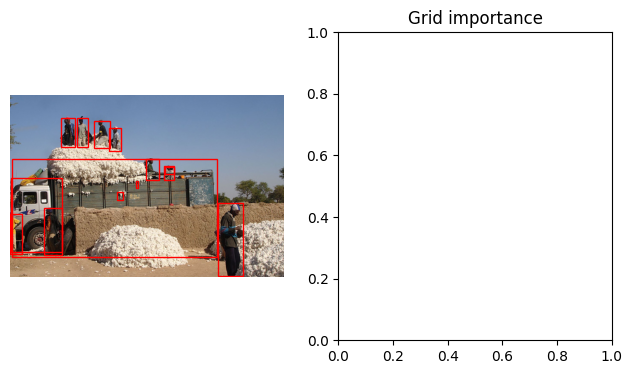

In [27]:
# Cell: Materialize model params, build train/val dataloaders if missing, run one epoch of training and quick eval.
# Assumes DLCTModelFull, build_dataloader, train_loop, evaluate_and_metrics, beam_search_batch, viz_sample, ITOS, PAD_IDX, DEVICE, H5_SOURCE, LR, NUM_WORKERS are defined in the notebook.
# Adjust small config values below if needed.

import torch
import traceback
from pathlib import Path

# CONFIG (tweak if needed)
EPOCHS_SANITY = 7
TRAIN_BATCH_SIZE = globals().get("BATCH_SIZE", 8)
VAL_BATCH_SIZE = 4
DUMMY_GRID_C = 256
DUMMY_FEAT_DIM = 1024
DUMMY_R = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Instantiate model if not already created
vocab_size = len(ITOS) if 'ITOS' in globals() else 10000
model = DLCTModelFull(vocab_size=vocab_size, d_model=D_MODEL, n_dec_layers=2, n_head=N_HEAD, d_ff=D_FF, memory_slots=20, pad_idx=PAD_IDX)
# tie weights if possible
try:
    model.output.weight = model.embed.weight
except Exception:
    pass
model = model.to(device)

# Materialize lazy params using an available collated batch if present, else use properly-sized dummy matching dataloader sample dims.
def materialize_model_with_batch(model):
    # prefer existing collated "batch" in global scope
    if 'batch' in globals() and isinstance(batch, dict):
        try:
            G = batch['G_grid'].to(device).float()
            R = batch['R_raw'].to(device).float()
            R_lens = batch.get('R_lens', None)
            if isinstance(R_lens, torch.Tensor):
                R_lens = R_lens.to(device)
            boxes_list = []
            for b in batch.get('boxes', []):
                if isinstance(b, torch.Tensor):
                    boxes_list.append(b.to(device).float())
                else:
                    boxes_list.append(torch.tensor(b, device=device, dtype=torch.float32))
            grid_cells_abs = batch.get('grid_cells_abs', None)
            if isinstance(grid_cells_abs, torch.Tensor):
                grid_cells_abs = grid_cells_abs.to(device).float()
            prior_gr = batch.get('prior_gr', None)
            if isinstance(prior_gr, torch.Tensor):
                prior_gr = prior_gr.to(device).float()
            print("Materializing using existing batch shapes G:", G.shape, "R:", R.shape)
            with torch.no_grad():
                encs, atts = model.forward_encoder(G, R, boxes=boxes_list, R_lens=R_lens, grid_cells_abs=grid_cells_abs, prior_gr=prior_gr)
            return True
        except Exception as e:
            print("Materialize with real batch failed:", e)
            traceback.print_exc()
    # fallback dummy with typical shapes from dataset sample
    B = 2
    GN = GRID_POOL * GRID_POOL
    grid_c = DUMMY_GRID_C
    Rn = DUMMY_R
    feat_dim = DUMMY_FEAT_DIM
    print(f"Materializing with dummy batch: B={B}, GN={GN}, grid_c={grid_c}, R={Rn}, feat_dim={feat_dim}")
    dummy_G = torch.zeros((B, GN, grid_c), dtype=torch.float32, device=device)
    dummy_R = torch.zeros((B, Rn, feat_dim), dtype=torch.float32, device=device)
    dummy_boxes = []
    for i in range(B):
        b = torch.zeros((Rn, 4), dtype=torch.float32, device=device)
        vals = torch.linspace(0.01, 0.3, steps=Rn, device=device)
        b[:,0] = vals; b[:,1] = vals; b[:,2] = b[:,0] + 0.05; b[:,3] = b[:,1] + 0.05
        dummy_boxes.append(b)
    dummy_R_lens = torch.tensor([Rn]*B, dtype=torch.long, device=device)
    xs = torch.linspace(0,1,GRID_POOL+1, device=device)
    ys = torch.linspace(0,1,GRID_POOL+1, device=device)
    cells = []
    for j in range(GRID_POOL):
        for i in range(GRID_POOL):
            cells.append([xs[i].item(), ys[j].item(), xs[i+1].item(), ys[j+1].item()])
    grid_cells = torch.tensor(cells, dtype=torch.float32, device=device).unsqueeze(0).expand(B, -1, -1)
    prior = torch.ones((B, Rn, GN), dtype=torch.float32, device=device) / float(GN)
    try:
        with torch.no_grad():
            encs, atts = model.forward_encoder(dummy_G, dummy_R, boxes=dummy_boxes, R_lens=dummy_R_lens, grid_cells_abs=grid_cells, prior_gr=prior)
        return True
    except Exception as e:
        print("Dummy materialize failed:", e)
        traceback.print_exc()
        return False

ok = materialize_model_with_batch(model)
if not ok:
    raise RuntimeError("Model materialization failed. Adjust DUMMY_GRID_C, DUMMY_FEAT_DIM, or ensure a collated 'batch' exists.")

# print param count now
total_params = sum(int(p.numel()) for p in model.parameters() if p is not None)
print(f"Model parameters: {total_params:,} ({total_params/1e6:.2f} M)")

# Build dataloaders if not present: try to use previously defined 'loader' for train and build val from H5_SOURCE
train_loader = globals().get('loader', None)
if train_loader is None:
    try:
        print("Building train dataloader from H5_SOURCE...")
        train_ds, train_loader = build_dataloader(H5_SOURCE, split='train', batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        print("Train dataset size:", len(train_ds))
    except Exception as e:
        print("Failed to build train loader:", e)
        train_loader = None

val_loader = globals().get('val_loader', None)
if val_loader is None:
    try:
        print("Building val dataloader from H5_SOURCE...")
        val_ds, val_loader = build_dataloader(H5_SOURCE, split='val', batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=max(1, NUM_WORKERS//2))
        print("Val dataset size:", len(val_ds))
    except Exception as e:
        print("Failed to build val loader:", e)
        val_loader = None

# Run one epoch of training (sanity)
if train_loader is None:
    raise RuntimeError("No train_loader available. Please create train_loader or define variable 'loader' pointing to it.")

print("Starting training sanity run...")
try:
    model = model.to(device)
    model = train_loop(model, train_loader, epochs=EPOCHS_SANITY, lr=LR, use_fp16=USE_FP16) if 'USE_FP16' in globals() else train_loop(model, train_loader, epochs=EPOCHS_SANITY, lr=LR)
    print("Training sanity run finished.")
except Exception as e:
    print("Training failed:", e)
    traceback.print_exc()

print("Done.")

In [ ]:
# Cell: Evaluate full metrics (BLEU/CIDEr/METEOR/ROUGE/SPICE if available) using ref_lookup.pkl and visualize samples.
# Usage: run evaluate_with_refs_and_viz(model, val_loader, "/kaggle/input/tokenizer-2/ref_lookup.pkl", n_images=200, beam_size=5, n_viz=5)
# Requires eval_and_viz_safe / beam_search_batch_safe / viz_sample_safe to be defined (fallbacks included).
import os, json, pickle
from pathlib import Path
from typing import Dict, List
from torch.utils.data import DataLoader

REF_PKL_PATH = Path("/kaggle/input/tokenizer-2/ref_lookup.pkl")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Try import COCO caption metrics
try:
    from pycocoevalcap.bleu.bleu import Bleu
    from pycocoevalcap.cider.cider import Cider
    from pycocoevalcap.meteor.meteor import Meteor
    from pycocoevalcap.rouge.rouge import Rouge
    from pycocoevalcap.spice.spice import Spice
    from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
    HAVE_COCO = True
except Exception as e:
    print("pycocoevalcap not available:", e)
    HAVE_COCO = False

# Helper: decode ref entry which may be strings or token lists
def decode_ref_entry(ent):
    # ent may be list[str] or list[list[int]] or dict
    if ent is None:
        return []
    if isinstance(ent, str):
        return [ent]
    if isinstance(ent, list):
        # if inner elements are strings
        if len(ent) == 0:
            return []
        if isinstance(ent[0], str):
            return ent
        # if inner elements are token id lists
        if isinstance(ent[0], (list, tuple)):
            out = []
            for toks in ent:
                words = []
                for t in toks:
                    ti = int(t)
                    if ti == PAD_IDX or ti == BOS_ID:
                        continue
                    if ti == EOS_ID:
                        break
                    w = ITOS[ti] if ti < len(ITOS) else "<unk>"
                    words.append(w)
                out.append(" ".join(words))
            return out
        # if it's a single list of ints
        if all(isinstance(x, int) for x in ent):
            words = []
            for t in ent:
                ti = int(t)
                if ti == PAD_IDX or ti == BOS_ID:
                    continue
                if ti == EOS_ID:
                    break
                w = ITOS[ti] if ti < len(ITOS) else "<unk>"
                words.append(w)
            return [" ".join(words)]
    # fallback
    return [str(ent)]

# Main evaluation function
def evaluate_with_refs_and_viz(model, loader, ref_pkl_path=REF_PKL_PATH, n_images=500, beam_size=5, n_viz=5):
    # load refs
    refs_map = {}
    if Path(ref_pkl_path).exists():
        try:
            with open(ref_pkl_path, "rb") as f:
                raw = pickle.load(f)
            # raw may be dict stem->list[str] or stem->list[list[int]]
            for k,v in raw.items():
                stem = Path(k).stem
                refs_map[stem] = decode_ref_entry(v)
            print(f"Loaded {len(refs_map)} reference entries from {ref_pkl_path}")
        except Exception as e:
            print("Failed to load ref pkl:", e)
            refs_map = {}
    else:
        print("Ref pkl not found at", ref_pkl_path)

    # ensure using single-worker eval loader to avoid warnings
    if getattr(loader, "num_workers", 0) > 0:
        eval_loader = DataLoader(loader.dataset, batch_size=loader.batch_size, shuffle=False, num_workers=0, collate_fn=loader.collate_fn, pin_memory=loader.pin_memory)
    else:
        eval_loader = loader

    # run safe eval (use beam_search_batch_safe if available)
    model.eval()
    hyps = {}
    collected_refs = {}
    seen = 0
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc="Eval (full)"):
            G = batch['G_grid'].to(DEVICE).float()
            R = batch['R_raw'].to(DEVICE).float()
            boxes = [b.to(DEVICE).float() for b in batch['boxes']]
            R_lens = batch['R_lens'].to(DEVICE).long()
            # generate sequences
            if 'beam_search_batch_safe' in globals():
                seqs = beam_search_batch_safe(model, G, R, boxes, R_lens, beam_size=beam_size)
            else:
                seqs = beam_search_batch(model, G, R, boxes, R_lens, beam_size=beam_size)
            for i, stem in enumerate(batch['stems']):
                # decode seq to text
                toks = seqs[i]
                words = []
                for t in toks:
                    ti = int(t)
                    if ti == PAD_IDX or ti == BOS_ID:
                        continue
                    if ti == EOS_ID:
                        break
                    w = ITOS[ti] if ti < len(ITOS) else "<unk>"
                    words.append(w)
                text = " ".join(words)
                hyps[stem] = text
                # fetch refs from ref_lookup if available, else empty list
                rlist = refs_map.get(stem, [])
                collected_refs[stem] = rlist if isinstance(rlist, list) else [str(rlist)]
                seen += 1
                if seen >= n_images:
                    break
            if seen >= n_images:
                break

    print(f"Collected {len(hyps)} hypotheses and {len(collected_refs)} reference entries")

    # Compute COCO metrics if available
    metrics = {}
    if HAVE_COCO and len(hyps) > 0:
        try:
            # prepare dicts in CocoEval format
            H = {k: [{'caption': v}] for k,v in hyps.items()}
            R = {k: [{'caption': s} for s in collected_refs.get(k, [])] for k in hyps.keys()}
            # fallback: ensure non-empty refs
            for k in R:
                if len(R[k]) == 0:
                    R[k] = [{'caption': ''}]
            tok = PTBTokenizer()
            H_tok = tok.tokenize(H); R_tok = tok.tokenize(R)
            b,_ = Bleu(4).compute_score(R_tok, H_tok); metrics.update({f'BLEU-{i+1}': float(b[i])*100 for i in range(4)})
            m,_ = Meteor().compute_score(R_tok, H_tok); metrics['METEOR'] = float(m)*100
            r,_ = Rouge().compute_score(R_tok, H_tok); metrics['ROUGE-L'] = float(r)*100
            c,_ = Cider().compute_score(R_tok, H_tok); metrics['CIDEr'] = float(c)*100
            try:
                s,_ = Spice().compute_score(R_tok, H_tok); metrics['SPICE'] = float(np.mean(s))*100
            except Exception:
                # SPICE often fails without Java; ignore
                pass
        except Exception as e:
            print("COCO metric computation failed:", e)
            metrics['error'] = str(e)

    # fallback simple UNK% metric
    total = 0; unk = 0
    for v in hyps.values():
        toks = v.split()
        total += len(toks); unk += sum(1 for t in toks if '<unk>' in t)
    metrics['UNK%'] = 100.0 * unk / max(1, total)

    print("Metrics:", metrics)

    # Print and visualize sample hypotheses with references
    sample_items = list(hyps.items())[:n_viz if 'n_viz' in locals() else 5]
    for stem, hyp in sample_items:
        refs_for = collected_refs.get(stem, [])
        print(f"\nStem: {stem}\n  HYP: {hyp}\n  REFS ({len(refs_for)}):")
        for rr in refs_for[:5]:
            print("   -", rr)
        # find the batch that contains this stem (use eval_loader with num_workers=0)
        found_batch = None
        for b in eval_loader:
            if b['stems'][0] == stem:
                found_batch = b; break
        if found_batch is not None:
            # compute seq for that batch again safely then visualize
            try:
                if 'beam_search_batch_safe' in globals():
                    seq = beam_search_batch_safe(model, found_batch['G_grid'].to(DEVICE).float(), found_batch['R_raw'].to(DEVICE).float(),
                                                 [bb.to(DEVICE).float() for bb in found_batch['boxes']], found_batch['R_lens'].to(DEVICE).long(), beam_size=beam_size)[0]
                else:
                    with torch.no_grad():
                        seq = beam_search_batch(model, found_batch['G_grid'].to(DEVICE).float(), found_batch['R_raw'].to(DEVICE).float(),
                                                [bb.to(DEVICE).float() for bb in found_batch['boxes']], found_batch['R_lens'].to(DEVICE).long(), beam_size=beam_size)[0]
                if 'viz_sample_safe' in globals():
                    viz_sample_safe(stem, found_batch, seq)
                else:
                    viz_sample(stem, found_batch, seq)
            except Exception as e:
                print("Visualization failed for", stem, e)
        else:
            print("Could not find batch for visualization of", stem)

    return metrics, list(hyps.items())[:n_viz]

# Example run
metrics, samples = evaluate_with_refs_and_viz(model, val_loader, REF_PKL_PATH, n_images=200, beam_size=5, n_viz=5)
print("Final metrics:", metrics)

Loaded 31014 reference entries from /kaggle/input/tokenizer-2/ref_lookup.pkl


Eval (full):   0%|          | 0/127 [00:00<?, ?it/s]

Collected 200 hypotheses and 200 reference entries


PTBTokenizer tokenized 2128 tokens at 25587.03 tokens per second.
PTBTokenizer tokenized 14301 tokens at 97427.36 tokens per second.


{'testlen': 1887, 'reflen': 1922, 'guess': [1887, 1687, 1487, 1287], 'correct': [1107, 381, 106, 17]}
ratio: 0.9817898022887712


/tmp/ipykernel_47/4195567632.py:148: ResourceWarning: unclosed file <_io.BufferedReader name=102>
  m,_ = Meteor().compute_score(R_tok, H_tok); metrics['METEOR'] = float(m)*100
/tmp/ipykernel_47/4195567632.py:148: ResourceWarning: unclosed file <_io.BufferedReader name=104>
  m,_ = Meteor().compute_score(R_tok, H_tok); metrics['METEOR'] = float(m)*100
